CUSTOMER SEGMENTATION

Dataset: 70,000 rows × 46 columns

RFM ANALYSIS

✓ RFM Scores calculated
✓ RFM Score range: 3 - 15

✓ RFM Segments defined:
RFM_Label
At Risk                14719
Potential Loyalists    14209
Loyal Customers        13906
Cant Lose Them         10805
Champions              10640
Lost                    5721
Name: count, dtype: int64

RFM VISUALIZATION


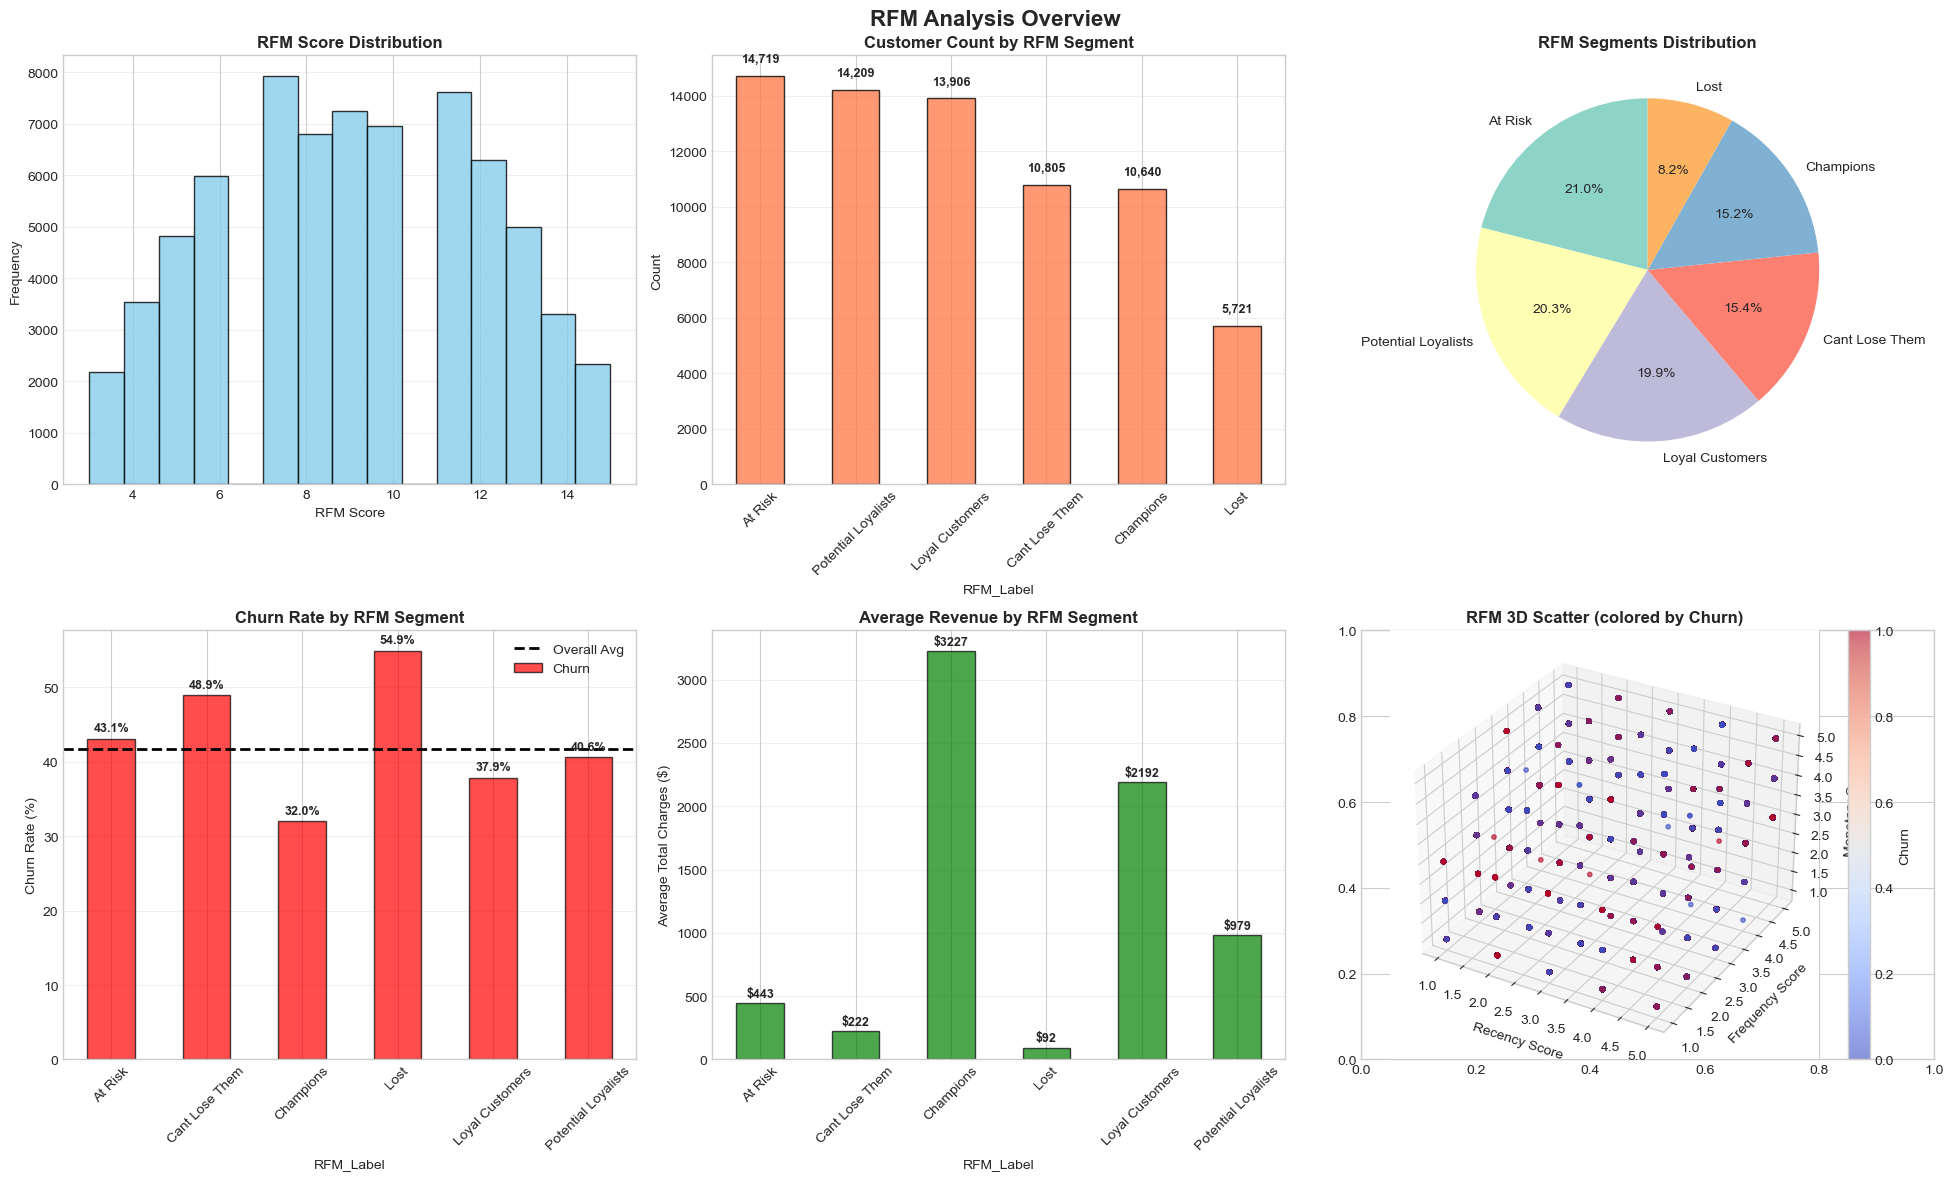


PREPARING DATA FOR CLUSTERING
✓ Selected 16 features for clustering
✓ Data scaled using StandardScaler
✓ Shape: (70000, 16)

FINDING OPTIMAL NUMBER OF CLUSTERS
K=2: Inertia=979700.79, Silhouette=0.199
K=3: Inertia=882335.69, Silhouette=0.149
K=4: Inertia=798042.09, Silhouette=0.161
K=5: Inertia=750657.53, Silhouette=0.116
K=6: Inertia=710995.88, Silhouette=0.114
K=7: Inertia=681958.81, Silhouette=0.115
K=8: Inertia=656202.02, Silhouette=0.117
K=9: Inertia=634272.66, Silhouette=0.110
K=10: Inertia=616343.46, Silhouette=0.112


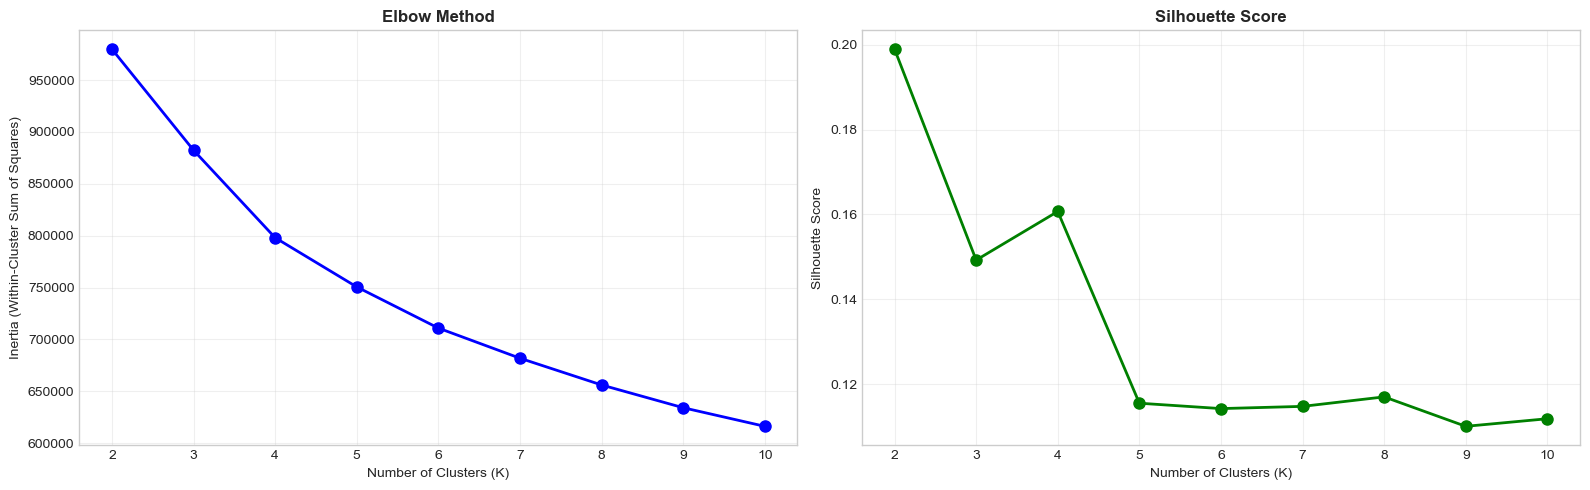


✓ Optimal K based on Silhouette Score: 2

K-MEANS CLUSTERING
✓ K-Means clustering completed with K=2
✓ Silhouette Score: 0.199
✓ Davies-Bouldin Index: 2.154
✓ Calinski-Harabasz Score: 10024.19

Cluster Distribution:
KMeans_Cluster
0    14412
1    55588
Name: count, dtype: int64

PCA VISUALIZATION
✓ PCA completed
✓ Explained variance ratio: [0.20690361 0.15637845]
✓ Total variance explained: 36.33%


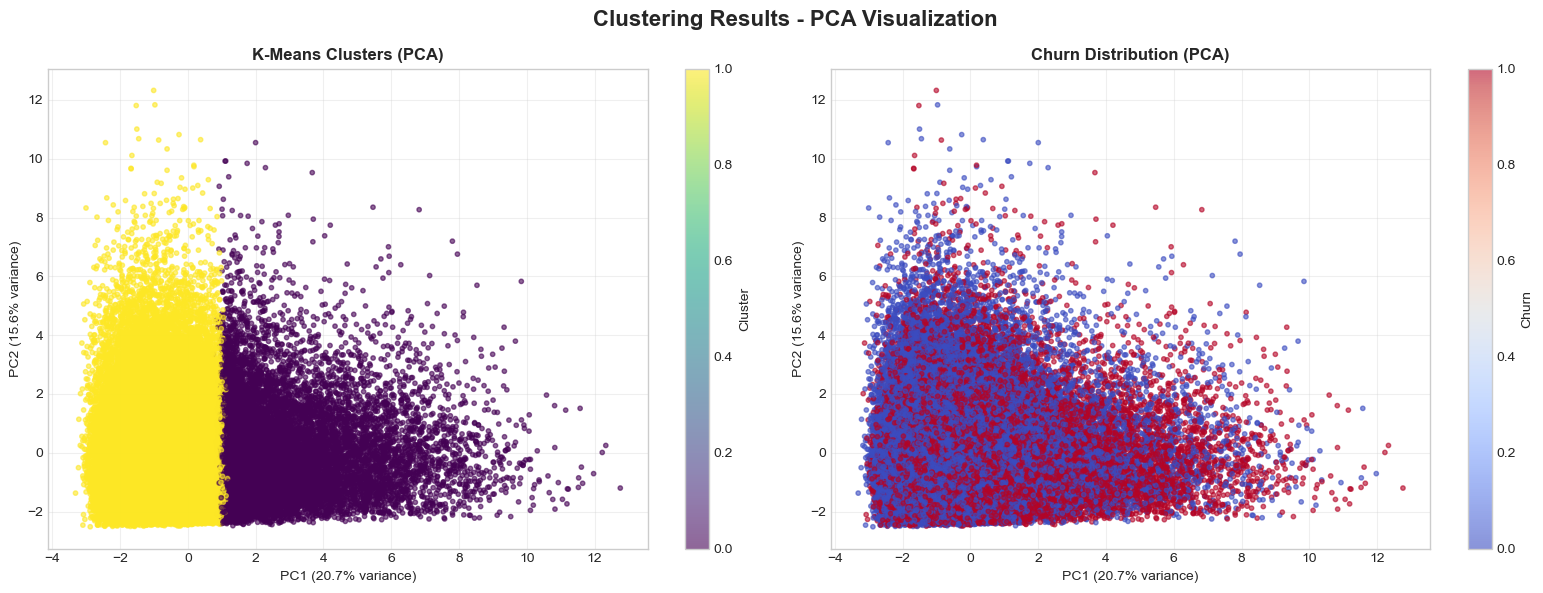


CLUSTER PROFILING - K-MEANS

Cluster Profiles (Mean Values):
                  Age  TenureMonths  MonthlyCharges  TotalCharges  \
KMeans_Cluster                                                      
0               41.92         22.95           51.62       1231.45   
1               41.87         23.59           52.49       1267.16   

                NumProducts  SupportCalls  SatisfactionScore  \
KMeans_Cluster                                                 
0                      3.46          3.95               5.69   
1                      3.53          2.43               7.35   

                AvgMonthlyUsageGB  LatePayments  DaysSinceLastInteraction  \
KMeans_Cluster                                                              
0                           58.99          2.01                     17.88   
1                           60.79          0.34                     13.54   

                 ARPU  EngagementScore  RiskScore  SatisfactionIndex  \
KMeans_Cluster         

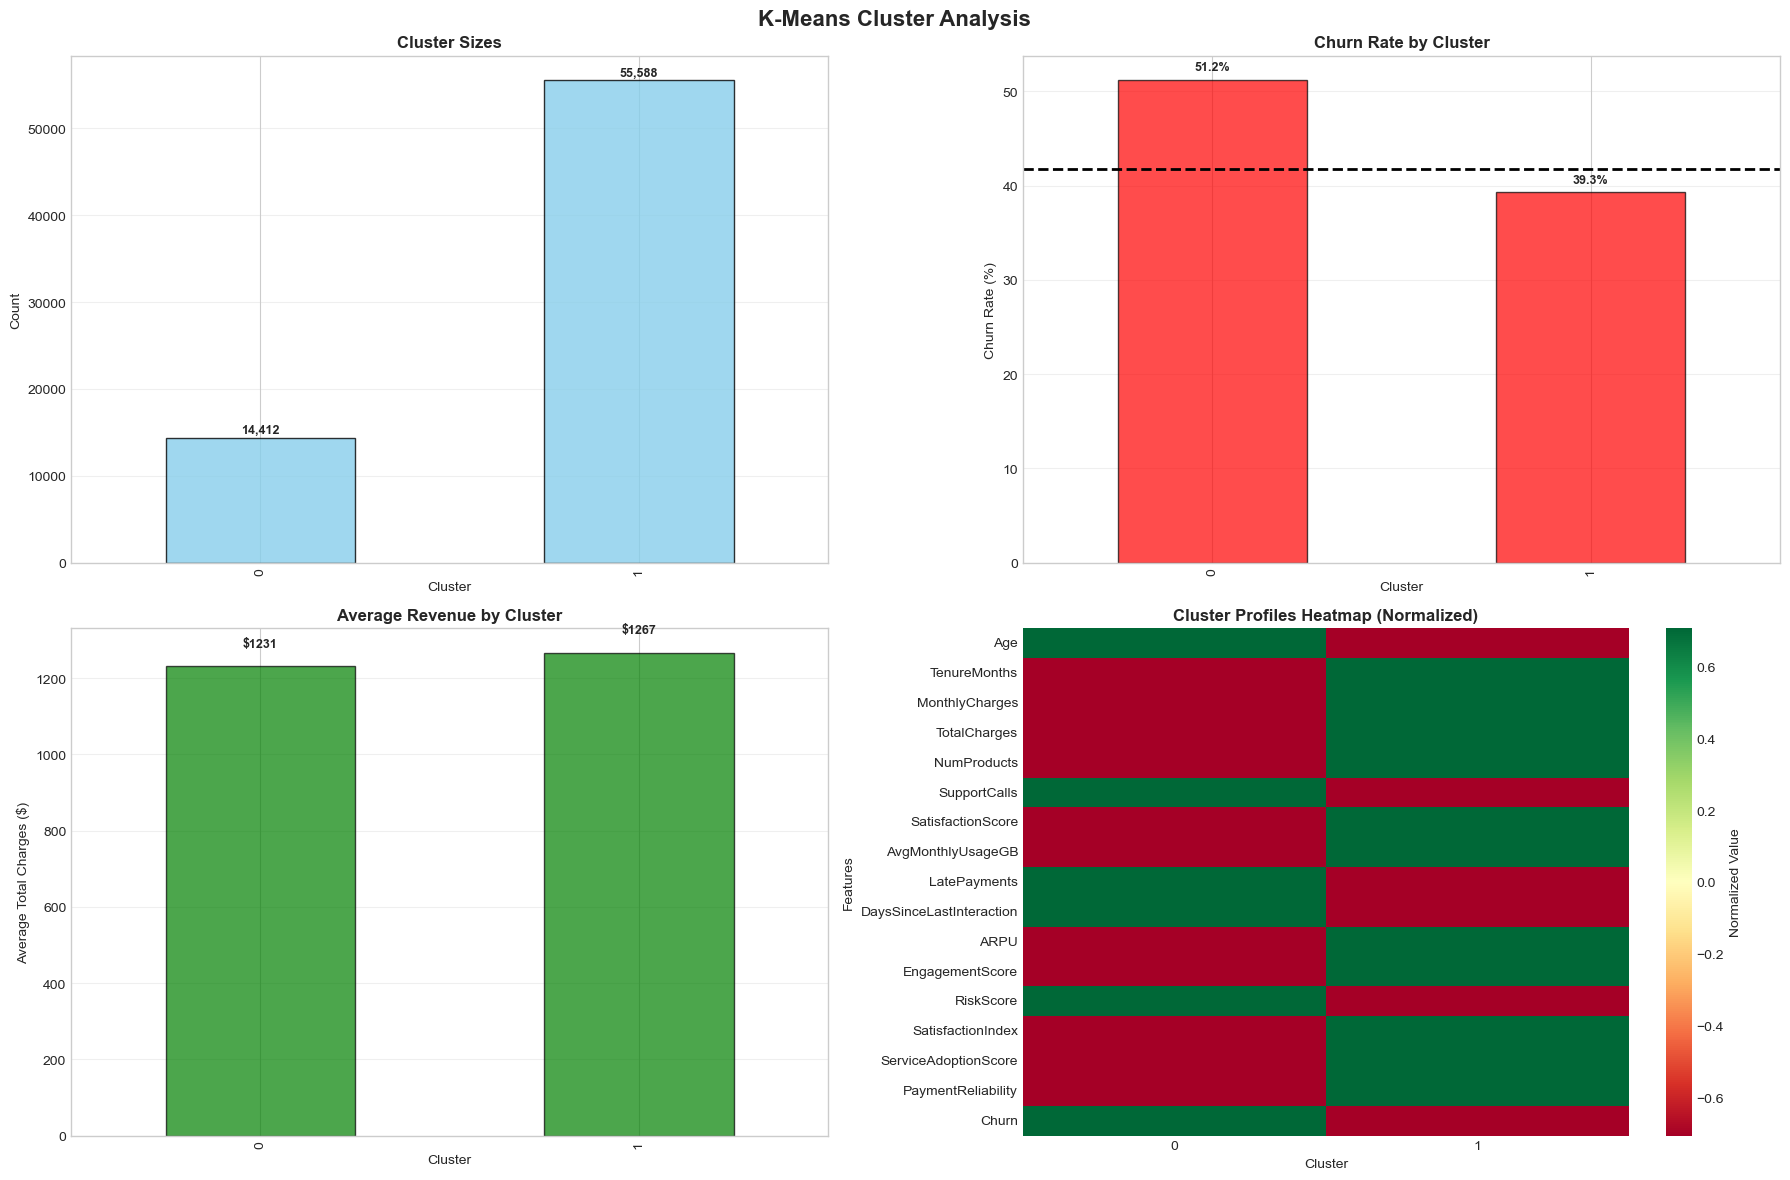


SAVING SEGMENTED DATA
✓ Saved: customer_churn_segmented.csv

SEGMENTATION SUMMARY
Total Customers: 70000
RFM Segments: 6
K-Means Clusters: 2
Features Used: 16
Overall Churn Rate: 41.74%

CUSTOMER SEGMENTATION COMPLETED


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 07: CUSTOMER SEGMENTATION (RFM + CLUSTERING)
# Purpose: Segment customers using RFM analysis and clustering algorithms
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('../data/processed/customer_churn_featured.csv')

print("="*80)
print("CUSTOMER SEGMENTATION")
print("="*80)
print(f"\nDataset: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. RFM ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("RFM ANALYSIS")
print("="*80)

# R: Recency (DaysSinceLastInteraction - lower is better)
# F: Frequency (TenureMonths - higher is better)
# M: Monetary (TotalCharges - higher is better)

df['R_Score'] = pd.qcut(df['DaysSinceLastInteraction'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
df['F_Score'] = pd.qcut(df['TenureMonths'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
df['M_Score'] = pd.qcut(df['TotalCharges'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

df['R_Score'] = df['R_Score'].astype(int)
df['F_Score'] = df['F_Score'].astype(int)
df['M_Score'] = df['M_Score'].astype(int)

df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']
df['RFM_Segment'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)

print("\n✓ RFM Scores calculated")
print(f"✓ RFM Score range: {df['RFM_Score'].min()} - {df['RFM_Score'].max()}")

def rfm_segment_label(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 11:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 9:
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= 7:
        return 'At Risk'
    elif row['RFM_Score'] >= 5:
        return 'Cant Lose Them'
    else:
        return 'Lost'

df['RFM_Label'] = df.apply(rfm_segment_label, axis=1)

print("\n✓ RFM Segments defined:")
print(df['RFM_Label'].value_counts())

# ═══════════════════════════════════════════════════════════════════════════════
# 3. RFM VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("RFM VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 3.1 RFM Score Distribution
df['RFM_Score'].hist(bins=15, ax=axes[0, 0], color='skyblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('RFM Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('RFM Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# 3.2 RFM Segments Count
segment_counts = df['RFM_Label'].value_counts()
segment_counts.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Customer Count by RFM Segment', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(segment_counts.values):
    axes[0, 1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# 3.3 RFM Segments Pie Chart
segment_counts.plot(kind='pie', ax=axes[0, 2], autopct='%1.1f%%', startangle=90, 
                     colors=sns.color_palette('Set3', len(segment_counts)))
axes[0, 2].set_title('RFM Segments Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('')

# 3.4 Churn Rate by RFM Segment
churn_by_rfm = df.groupby('RFM_Label')['Churn'].mean() * 100
churn_by_rfm.plot(kind='bar', ax=axes[1, 0], color='red', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Churn Rate by RFM Segment', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axhline(df['Churn'].mean() * 100, color='black', linestyle='--', linewidth=2, label='Overall Avg')
axes[1, 0].legend()

for i, v in enumerate(churn_by_rfm.values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 3.5 Average Revenue by RFM Segment
revenue_by_rfm = df.groupby('RFM_Label')['TotalCharges'].mean()
revenue_by_rfm.plot(kind='bar', ax=axes[1, 1], color='green', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Average Revenue by RFM Segment', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Total Charges ($)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(revenue_by_rfm.values):
    axes[1, 1].text(i, v + 50, f'${v:.0f}', ha='center', fontsize=9, fontweight='bold')

# 3.6 RFM 3D Scatter
ax = fig.add_subplot(2, 3, 6, projection='3d')
scatter = ax.scatter(df['R_Score'], df['F_Score'], df['M_Score'], 
                     c=df['Churn'], cmap='coolwarm', alpha=0.6, s=10)
ax.set_xlabel('Recency Score', fontsize=10)
ax.set_ylabel('Frequency Score', fontsize=10)
ax.set_zlabel('Monetary Score', fontsize=10)
ax.set_title('RFM 3D Scatter (colored by Churn)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Churn')

plt.suptitle('RFM Analysis Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/results/07_rfm_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. PREPARE DATA FOR CLUSTERING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PREPARING DATA FOR CLUSTERING")
print("="*80)

clustering_features = [
    'Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 
    'NumProducts', 'SupportCalls', 'SatisfactionScore', 
    'AvgMonthlyUsageGB', 'LatePayments', 'DaysSinceLastInteraction',
    'ARPU', 'EngagementScore', 'RiskScore', 'SatisfactionIndex',
    'ServiceAdoptionScore', 'PaymentReliability'
]

X = df[clustering_features].copy()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Selected {len(clustering_features)} features for clustering")
print(f"✓ Data scaled using StandardScaler")
print(f"✓ Shape: {X_scaled.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow curve
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(alpha=0.3)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/results/07_optimal_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal K based on Silhouette Score: {optimal_k}")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. K-MEANS CLUSTERING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=8)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✓ K-Means clustering completed with K={optimal_k}")
print(f"✓ Silhouette Score: {silhouette_score(X_scaled, df['KMeans_Cluster']):.3f}")
print(f"✓ Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df['KMeans_Cluster']):.3f}")
print(f"✓ Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, df['KMeans_Cluster']):.2f}")

print("\nCluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# ═══════════════════════════════════════════════════════════════════════════════
# 7. PCA VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PCA VISUALIZATION")
print("="*80)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"✓ PCA completed")
print(f"✓ Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"✓ Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], 
                           cmap='viridis', alpha=0.6, s=10)
axes[0].set_title('K-Means Clusters (PCA)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')
axes[0].grid(alpha=0.3)

# Churn overlay
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Churn'], 
                           cmap='coolwarm', alpha=0.6, s=10)
axes[1].set_title('Churn Distribution (PCA)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter2, ax=axes[1], label='Churn')
axes[1].grid(alpha=0.3)

plt.suptitle('Clustering Results - PCA Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/results/07_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 8. CLUSTER PROFILING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CLUSTER PROFILING - K-MEANS")
print("="*80)

cluster_profile = df.groupby('KMeans_Cluster')[clustering_features + ['Churn']].mean()

print("\nCluster Profiles (Mean Values):")
print(cluster_profile.round(2))

# Churn rate per cluster
churn_by_cluster = df.groupby('KMeans_Cluster')['Churn'].mean() * 100
print("\nChurn Rate by Cluster:")
print(churn_by_cluster.round(2))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Cluster sizes
cluster_sizes = df['KMeans_Cluster'].value_counts().sort_index()
cluster_sizes.plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Cluster Sizes', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(cluster_sizes.values):
    axes[0, 0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Churn rate by cluster
churn_by_cluster.plot(kind='bar', ax=axes[0, 1], color='red', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Churn Rate by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axhline(df['Churn'].mean() * 100, color='black', linestyle='--', linewidth=2)

for i, v in enumerate(churn_by_cluster.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Average revenue by cluster
revenue_by_cluster = df.groupby('KMeans_Cluster')['TotalCharges'].mean()
revenue_by_cluster.plot(kind='bar', ax=axes[1, 0], color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Revenue by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Total Charges ($)')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(revenue_by_cluster.values):
    axes[1, 0].text(i, v + 50, f'${v:.0f}', ha='center', fontsize=9, fontweight='bold')

# Heatmap - cluster profiles
cluster_profile_normalized = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
sns.heatmap(cluster_profile_normalized.T, annot=False, cmap='RdYlGn', center=0, 
            ax=axes[1, 1], cbar_kws={'label': 'Normalized Value'})
axes[1, 1].set_title('Cluster Profiles Heatmap (Normalized)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Features')

plt.suptitle('K-Means Cluster Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/results/07_cluster_profiling.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 9. SAVE SEGMENTED DATA
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SAVING SEGMENTED DATA")
print("="*80)

df.to_csv('../data/processed/customer_churn_segmented.csv', index=False)
print("✓ Saved: customer_churn_segmented.csv")

# ═══════════════════════════════════════════════════════════════════════════════
# 10. SEGMENTATION SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SEGMENTATION SUMMARY")
print("="*80)

summary = {
    'Total Customers': len(df),
    'RFM Segments': df['RFM_Label'].nunique(),
    'K-Means Clusters': df['KMeans_Cluster'].nunique(),
    'Features Used': len(clustering_features),
    'Overall Churn Rate': f"{df['Churn'].mean() * 100:.2f}%"
}

for key, value in summary.items():
    print(f"{key}: {value}")

print("\n" + "="*80)
print("CUSTOMER SEGMENTATION COMPLETED")
print("="*80)
